In [2]:
import os

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import openpyxl
import pandas as pd
import seaborn as sns 

In [3]:
file_path = './dataset/datasets_riesgo_v2.xlsx'

df_cartera = pd.read_excel(file_path, sheet_name='cartera', decimal=',')
df_pagos = pd.read_excel(file_path, sheet_name='pagos', decimal=',')

df_pagos['fecha_vencimiento'] = pd.to_datetime(df_pagos['fecha_vencimiento'])
df_pagos['fecha_pago_real'] = pd.to_datetime(df_pagos['fecha_pago_real'])
df_cartera['fecha_originacion'] = pd.to_datetime(df_cartera['fecha_originacion'])

print(f"Cartera cargada: {df_cartera.shape[0]} registros.")
print(f"Pagos cargados: {df_pagos.shape[0]} registros.")

Cartera cargada: 400 registros.
Pagos cargados: 1349 registros.


In [4]:
mora_por_prestamo = duckdb.query("""
    SELECT 
        id_prestamo,
        COUNT(*) AS cuotas_vencidas,
        MAX(current_date - fecha_vencimiento) AS dias_mora_calculados,
        SUM(monto_cuota) AS capital_en_mora
    FROM df_pagos
    WHERE fecha_pago_real IS NULL 
      AND fecha_vencimiento < '2026-05-14'
    GROUP BY id_prestamo
""").df()

df_cartera_final = df_cartera.merge(mora_por_prestamo, on='id_prestamo', how='left')

df_cartera_final['estado_analista'] = np.where(
    df_cartera_final['cuotas_vencidas'] > 0, 
    'Mora Reclasificada', 
    df_cartera_final['estado_actual']
)

df_cartera_final['dias_mora_calculados'] = df_cartera_final['dias_mora_calculados'].fillna(0)

Consultas analiticas

•	a) ¿Cuál es la tasa de mora (+30 días) por producto? ¿Y por cosecha trimestral de originación?

In [5]:
tasa_de_mora_mas30dias = """
SELECT 
    producto,
    count(case when dias_mora>30 then 1 end) as mora,
    count(*) as total,
    round(count(case when dias_mora>30 then 1 end) * 100 / count(*), 2) as tasa_mora_porcentaje
FROM df_cartera_final as c
group by producto
"""

df_mora30dias = duckdb.query(tasa_de_mora_mas30dias).df()
df_mora30dias

,producto,mora,total,tasa_mora_porcentaje
0,BNPL,30,99,30.30
1,Microcrédito,19,94,20.21
2,Adelanto de Sueldo,32,100,32.00
3,Préstamo Personal,25,107,23.36


El análisis revela que las líneas de financiamiento orientadas al consumo inmediato (Adelanto de Sueldo y BNPL) presentan el perfil más crítico de la cartera, con casi un tercio de sus créditos en mora pesada (32% y 30.30% respectivamente). Este comportamiento duplica la tasa observada en el producto Préstamo Personal y supera por 12 puntos porcentuales a Microcrédito, evidenciando que el riesgo está fuertemente concentrado en los productos de menor barrera de entrada

•	b) ¿Cuál es la distribución del saldo en mora por canal de adquisición?

In [6]:
tasa_de_mora_por_canal = """
SELECT 
    canal_adquisicion,
    SUM(CASE WHEN dias_mora > 0 THEN saldo_capital ELSE 0 END) AS saldo_en_mora,
    COUNT(CASE WHEN dias_mora > 0 THEN 1 END) AS cantidad_prestamos_mora,
    ROUND(COUNT(CASE WHEN dias_mora > 0 THEN 1 END) * 100.0 / COUNT(*), 2) AS tasa_mora_porcentaje
FROM df_cartera_final
GROUP BY canal_adquisicion
ORDER BY saldo_en_mora DESC
"""


df_mora_por_canal = duckdb.query(tasa_de_mora_por_canal).df()
df_mora_por_canal

,canal_adquisicion,saldo_en_mora,cantidad_prestamos_mora,tasa_mora_porcentaje
0,Alianza Comercial,449826.98,39,43.82
1,Orgánico,399817.50,33,41.25
2,Paid Social,327808.45,30,38.46
3,Referido,326121.16,32,40.51
4,App Store,274596.27,25,33.78


El análisis por canal demuestra que el riesgo financiero no está distribuido de manera uniforme, identificando a Alianza Comercial como el canal más crítico en términos absolutos, al concentrar la mayor masa de capital deudor ($449.826,98) y la mayor tasa de incidencia de clientes morosos (43.82%).

Sin embargo, el hallazgo más relevante para el negocio surge al analizar el ticket promedio de la mora: el canal Orgánico, a pesar de tener una menor cantidad de contratos afectados que Alianza Comercial (33 vs 39), presenta la deuda promedio por deudor más alta de toda la operación ($12.115).

Mientras que en Alianza Comercial el problema es de volumen masivo de clientes defectuosos, en el canal Orgánico el riesgo está en la magnitud del ticket otorgado

•	c) ¿Cuántas cuotas se pagaron con atraso vs. a tiempo, y cuál es el promedio de días de atraso por segmento?

In [7]:
cuotas_info = """
SELECT 
    c.segmento_cliente,
    COUNT(CASE WHEN p.fecha_pago_real IS NOT NULL AND p.dias_atraso <= 0 THEN 1 END) AS cuotas_pagadas_a_tiempo,
    COUNT(CASE WHEN p.fecha_pago_real IS NOT NULL AND p.dias_atraso > 0 THEN 1 END) AS cuotas_pagadas_con_atraso,
    COUNT(CASE WHEN p.fecha_pago_real IS NULL AND p.fecha_vencimiento < '2026-05-14' THEN 1 END) AS cuotas_vencidas_impagas,
    
    COUNT(*) AS total_cuotas,

    ROUND(AVG(CASE WHEN p.dias_atraso > 0 THEN p.dias_atraso END), 1) AS promedio_dias_atraso
FROM df_pagos AS p
INNER JOIN df_cartera_final AS c 
    ON p.id_prestamo = c.id_prestamo
GROUP BY c.segmento_cliente
ORDER BY total_cuotas DESC
"""


df_cuotas_info = duckdb.query(cuotas_info).df()
df_cuotas_info

,segmento_cliente,cuotas_pagadas_a_tiempo,cuotas_pagadas_con_atraso,cuotas_vencidas_impagas,total_cuotas,promedio_dias_atraso
0,Premium,247,103,46,396,17.8
1,Nuevo,205,71,44,320,16.3
2,Recurrente,203,87,27,317,16.4
3,Inactivo,202,80,34,316,16.6


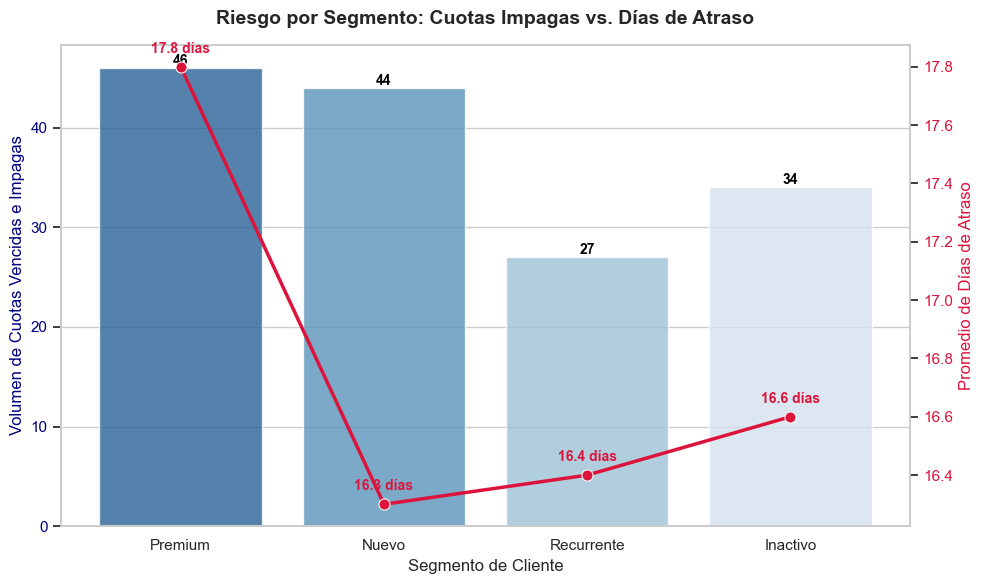

In [11]:

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 6))


sns.barplot(
    x="segmento_cliente", 
    y="cuotas_vencidas_impagas", 
    data=df_cuotas_info, 
    ax=ax1, 
    hue="segmento_cliente",  
    palette="Blues_r",
    alpha=0.8,
    legend=False            
)

ax1.set_title("Riesgo por Segmento: Cuotas Impagas vs. Días de Atraso", fontsize=14, pad=15, fontweight="bold")
ax1.set_xlabel("Segmento de Cliente", fontsize=12)
ax1.set_ylabel("Volumen de Cuotas Vencidas e Impagas", color="navy", fontsize=12)
ax1.tick_params(axis="y", labelcolor="navy")

for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height())}", 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha="center", va="bottom", fontsize=10, fontweight="bold", color="black")

ax2 = ax1.twinx() 
sns.lineplot(
    x="segmento_cliente", 
    y="promedio_dias_atraso", 
    data=df_cuotas_info, 
    ax=ax2, 
    color="crimson", 
    marker="o", 
    linewidth=2.5, 
    markersize=8,
    sort=False
)

ax2.set_ylabel("Promedio de Días de Atraso", color="crimson", fontsize=12)
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.grid(False)

for x, y in zip(df_cuotas_info["segmento_cliente"], df_cuotas_info["promedio_dias_atraso"]):
    ax2.annotate(f"{y} días", 
                 (x, y), 
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha="center", fontsize=10, fontweight="bold", color="crimson")

plt.tight_layout()
plt.show()

El análisis del comportamiento de pago revela que el segmento Premium presenta los indicadores de mayor rezago operativo en la cartera, registrando el promedio de días de atraso más elevado (17.8 días) y el mayor volumen absoluto de incumplimiento, con 46 cuotas vencidas e impagas.

En contraposición, el segmento Recurrente demuestra el perfil más eficiente para el flujo de caja, ya que mantiene el menor volumen de cuotas vencidas sin pagar (27 cuotas). Por su parte, el segmento Nuevo muestra un volumen considerable de morosidad temprana (44 cuotas vencidas impagas), a pesar de registrar el promedio de días de atraso más bajo cuando logra regularizar sus pagos (16.3 días).

ADICIONAL: ¿Qué país tiene el mayor Capital en Riesgo real y qué tasa de interés promedio maneja?

In [9]:
capital_de_riesgo = """
SELECT 
    pais,
    SUM(CASE WHEN dias_mora > 0 THEN saldo_capital ELSE 0 END) AS capital_en_mora,
    ROUND(
        SUM(CASE WHEN dias_mora > 0 THEN saldo_capital ELSE 0 END) * 100.0 / (SELECT SUM(saldo_capital) FROM df_cartera_final WHERE dias_mora > 0), 2) AS porcentaje_distribucion_riesgo,
    ROUND(AVG(tna), 2) AS tna_promedio_entregada,
    COUNT(CASE WHEN dias_mora > 0 THEN 1 END) AS prestamos_en_mora
FROM df_cartera_final
GROUP BY pais
ORDER BY capital_en_mora DESC
"""


df_capital_de_riesgo = duckdb.query(capital_de_riesgo).df()
df_capital_de_riesgo

,pais,capital_en_mora,porcentaje_distribucion_riesgo,tna_promedio_entregada,prestamos_en_mora
0,UY,685792.77,38.57,0.45,61
1,PY,560386.70,31.51,0.45,49
2,AR,531990.89,29.92,0.42,49


El análisis geográfico identifica a Uruguay (UY) como el mercado con mayor Capital en Riesgo real de la compañía, alcanzando $685.792,77 y concentrando de manera aislada el 38.57% del riesgo global de la cartera, bajo una TNA promedio del 45%. En contraste, Argentina (AR) se posiciona como la plaza con menor exposición financiera, representando el 29.92% del capital en mora y registrando también el costo de crédito más bajo (42% TNA).

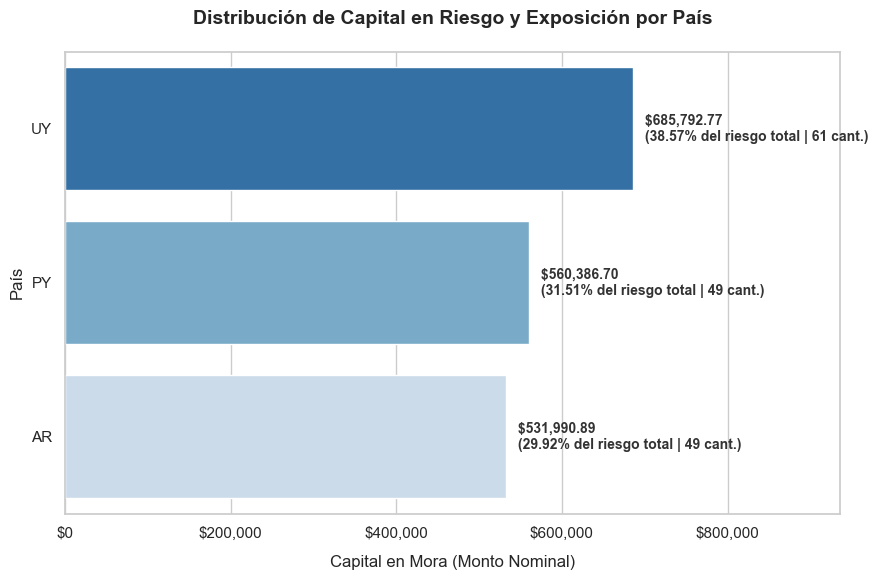

In [10]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x="capital_en_mora", 
    y="pais", 
    hue="pais",
    data=df_capital_de_riesgo, 
    palette="Blues_r",
    legend=False,
    ax=ax
)

ax.set_title("Distribución de Capital en Riesgo y Exposición por País", fontsize=14, pad=20, weight='bold')
ax.set_xlabel("Capital en Mora (Monto Nominal)", fontsize=12, labelpad=10)
ax.set_ylabel("País", fontsize=12)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))

for i, row in df_capital_de_riesgo.iterrows():
    monto = row['capital_en_mora']
    porcentaje = row['porcentaje_distribucion_riesgo']
    contratos = row['prestamos_en_mora']
    
    texto_etiqueta = f" ${monto:,.2f}\n ({porcentaje}% del riesgo total | {contratos} cant.)"
    
    ax.text(
        monto + 10000,
        i, 
        texto_etiqueta, 
        va='center', 
        fontsize=10, 
        fontweight='semibold',
        color='#333333'
    )

ax.set_xlim(0, df_capital_de_riesgo['capital_en_mora'].max() + 250000)

plt.savefig("capital_en_riesgo_pais.png", bbox_inches='tight', dpi=300)